# Section 01 - Getting ready

In [96]:
import numpy as np
import pandas as pd
from plotnine import *
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Image
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [97]:
genotype_growth = pd.read_csv('../Datasets/ExData9/genotype_growth.csv')
genotype_growth = genotype_growth[['strain', 'gene', 'genotype', 'growth_rate']]
genotype_growth.head()

,strain,gene,genotype,growth_rate
0,seg_01B,gene_1,Lab strain,6.720447
1,seg_01B,gene_14,Lab strain,6.720447
2,seg_01B,gene_27,Lab strain,6.720447
3,seg_01B,gene_40,Lab strain,6.720447
4,seg_01B,gene_54,Lab strain,6.720447


# Section 02 - Find genes associated with growth rate

Recall the yeast dataset from the previous exercises and lecture, which analyses the genetic determinants
of yeast growth rates. We look at three genes, for simplicity called A, B and C, of which each yeast can
have one of two variants: “wild” or “lab”. We want to determine whether the different variants of these
genes are associated with differences in growth rate. 

Report genes significantly associating with growth rate in maltose. We would like the expected ratio of
false discoveries among the reported significant genes to not exceed 5%.

To do so, run a Wilcoxon test for growth rate versus the genotype at each of the 1,000 genes Remember
that we tested this relationship for one specific gene last time. Plot a histogram and a Q-Q plot of
the obtained 𝑃-values. Which ones would you consider significant and why? Do we need to correct for
multiple testing? If yes, which correction would you apply?

Hint: plot 𝑃-values in -log10 scale. Use `ppoints(pval, a=0)` to generate the expected quantiles
according to the uniform distribution, i.e. 1/(𝑛 + 1), … , 𝑛/(𝑛 + 1). 

Note that this is similar to using geom_qq and then log-scaling the axes, except that we want to log-scale and also reverse.

In [98]:
from scipy.stats import mannwhitneyu

def get_pval(df):
    groups = df['genotype'].unique()
    
    return mannwhitneyu(
        df[ df['genotype'] == groups[0]]['growth_rate'],
        df[ df['genotype'] == groups[1]]['growth_rate']
    ).pvalue

In [99]:
test_res = genotype_growth.groupby('gene').apply(
    lambda g : pd.Series(get_pval(g))
).reset_index().rename(columns= {0:'p_val'})

test_res.head()

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_22420/755921536.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,gene,p_val
0,gene_1,0.984131
1,gene_1000,0.029077
2,gene_10009,0.464069
3,gene_10022,0.313969
4,gene_10035,0.347852


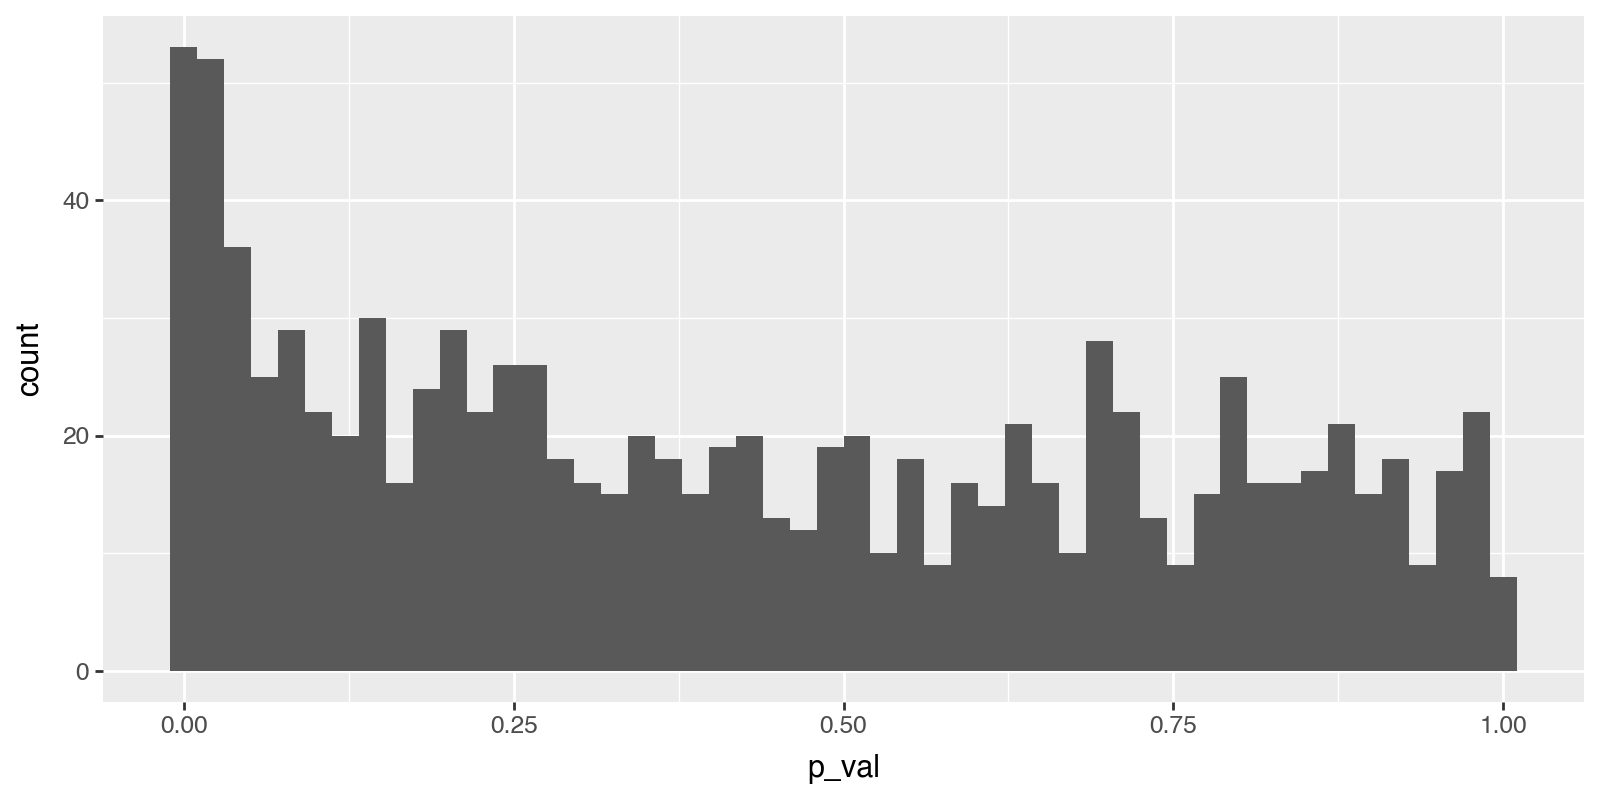

In [100]:
(
    ggplot(test_res, aes('p_val')) + 
    geom_histogram(bins = 50) +
    theme(figure_size=(8,4))
)

In [101]:
test_res.sort_values(by = 'p_val', inplace= True)
n = len(test_res)

test_res['log_exp'] = -np.log10(np.arange(1, n+1) / n)
test_res['log_pval'] = -np.log10(test_res['p_val'])

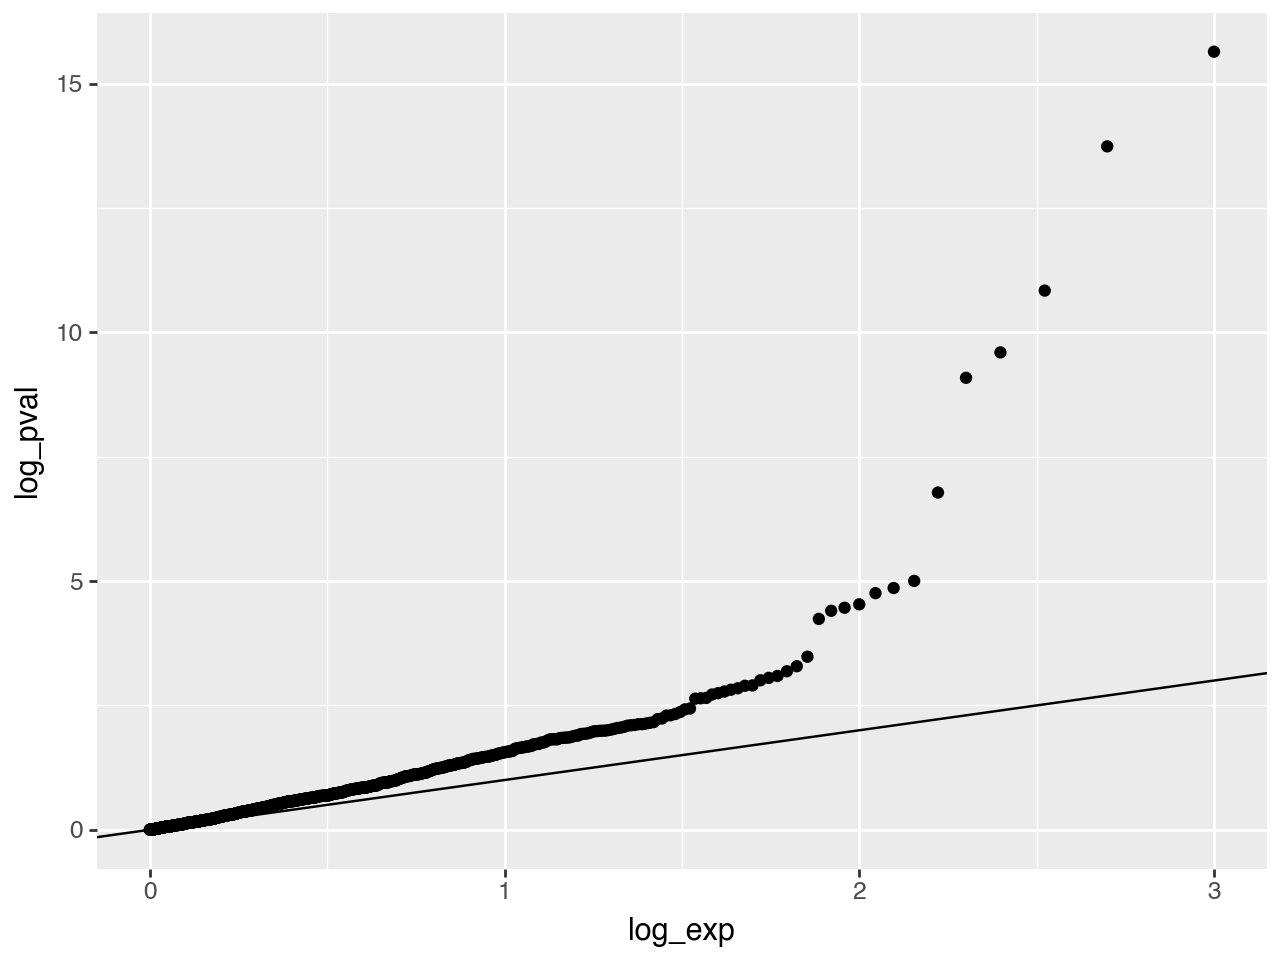

In [102]:
(
    ggplot(test_res, aes('log_exp', 'log_pval')) + 
    geom_point() +
    geom_abline(intercept = 0, slope = 1)
)

We need to correct for multiple testing, as we just made 1000 tests.

Since we want to keep the expected ratio of false discoveries smaller or equal to 0.05, we need Benjamini-Hochberg correction, which is implemented in the multipletests function.

In [103]:
test_res['padj'] = multipletests(test_res['p_val'], method = 'fdr_bh')[1]
test_res[test_res['padj'] <= 0.05].sort_values('padj').head()

,gene,p_val,log_exp,log_pval,padj
601,gene_5211,2.264386e-16,3.000000,15.645049,2.264386e-13
599,gene_5198,1.813867e-14,2.698970,13.741395,9.069334e-12
598,gene_5184,1.440971e-11,2.522879,10.841345,4.803237e-09
597,gene_5171,2.518482e-10,2.397940,9.598861,6.296204e-08
596,gene_5158,8.174932e-10,2.301030,9.087516,1.634986e-07


2. Let’s look at the effect sizes of the most significant genes. For the 5 most significant genes, plot the
difference in growth rate of yeast with a “wild” and “lab” variant.

In [104]:
top_genes = test_res[test_res['padj'] <= 0.05].sort_values('padj')['gene'].head(5)

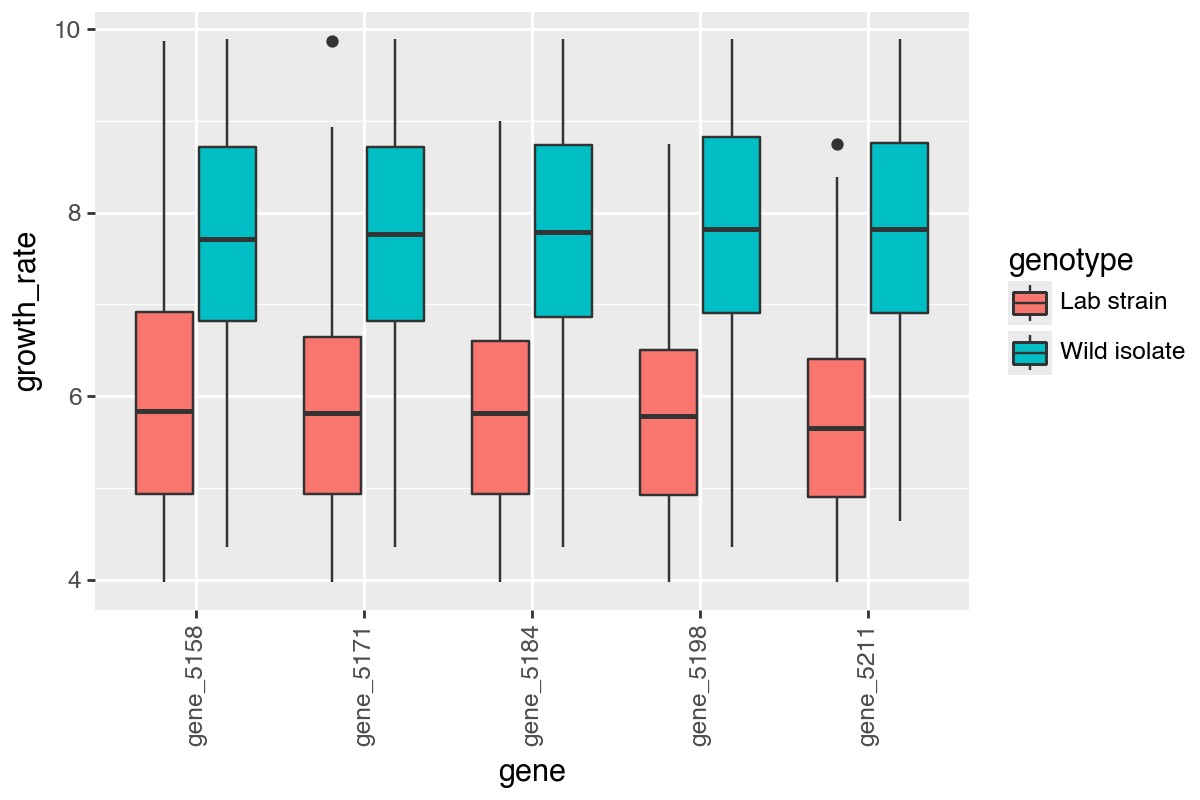

In [105]:
(
    ggplot(genotype_growth[genotype_growth['gene'].isin(top_genes)], aes('gene', 'growth_rate', fill = 'genotype')) +
    geom_boxplot() + 
    theme(figure_size= (6,4)) + 
    theme(axis_text_x= element_text(angle = 90))
)

Now we load the data table genomic position, that provides information of the genes’ positions on
chromosomes. The genomic position is defined by the chromosome the gene is on and the gene’s position
within that chromosome.

In [106]:
genomic_position = pd.read_csv('../Datasets/ExData9/genomic_position.csv')
genomic_position.head()

,Unnamed: 0,id,chrom,start,end
0,0,gene_1,chr01,1512,2366
1,1,gene_14,chr01,29161,29333
2,2,gene_27,chr01,38275,38317
3,3,gene_40,chr01,47695,47695
4,4,gene_54,chr01,56059,56059


3. Plot the 𝑃-values against genomic position. Do you see positions that are associated with growth?

Hint: plot 𝑃-values in -log10 scale. Use the start column from the gene table as position. Additionally,
facet on the chrom column (because the start column indicates the genomic position of the gene within
its particular chromosome).

In [107]:
genomic_position = pd.merge(genomic_position, test_res[['gene', 'p_val','padj']], how= 'left', left_on = 'id', right_on = 'gene').drop(columns = 'gene')

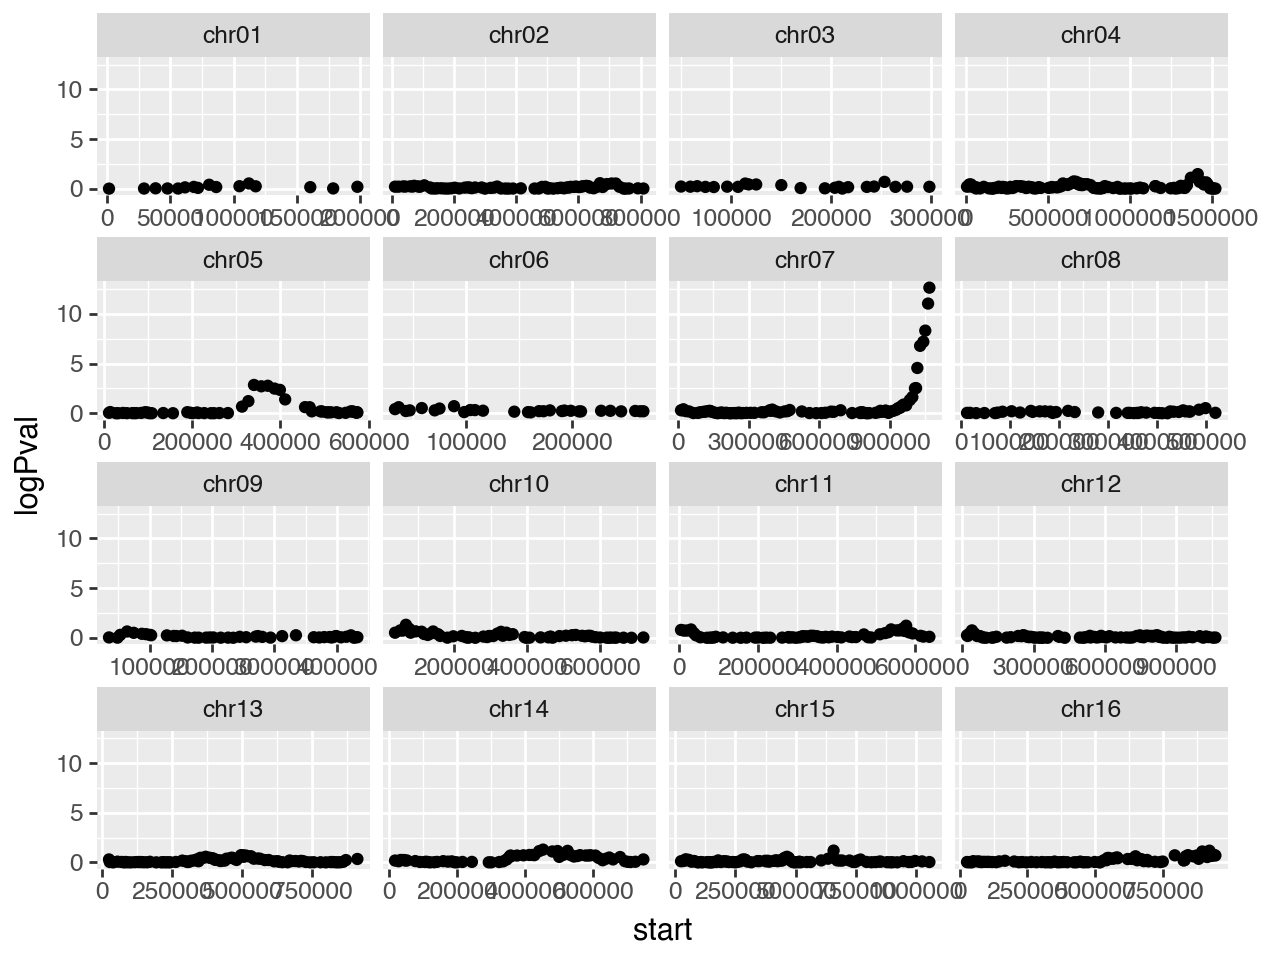

In [108]:
genomic_position.sort_values(by = ['chrom', 'start'], inplace = True)
genomic_position['logPval'] = -np.log10(genomic_position['padj'])

(
    ggplot(genomic_position, aes('start', 'logPval')) + 
    geom_point() +
    facet_wrap('~chrom', scales= 'free_x')
)

4. How many genes are nominally significantly associated with growth (𝛼 = 0.05)? How many genes are
found when using a false discovery rate cutoff of 0.05?

In [109]:
print((genomic_position['p_val'] <= 0.05).sum())

139


In [110]:
print((genomic_position['padj'] <= 0.05).sum())

18


# Section 03 - Let’s do many tests

1. Consider the dataset mtcars. Find all pairs of quantitative variables that show significant association
(at the 5% level) with each other. Do not make any assumptions of distribution.

Below we give you code, that computes maximum absolute difference between 2 variables for each pair
of quantitative variables. We use the combinations() function from the package itertools to get all
possible combinations from a list.

In [111]:
import statsmodels.api as sm
from itertools import combinations

In [112]:
cars = sm.datasets.get_rdataset('mtcars').data
cars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [113]:
cols = ["mpg", "disp", "hp", "drat", "wt", "qsec"]
pairs = pd.DataFrame(list(combinations(cols, 2)), columns=['var1', 'var2'])
pairs.head()

,var1,var2
0,mpg,disp
1,mpg,hp
2,mpg,drat
3,mpg,wt
4,mpg,qsec


In [114]:
pairs['max_abs'] = [
    (cars[row.var1] - cars[row.var2]).abs().max()
    for row in pairs.itertuples()
]

pairs.head()

,var1,var2,max_abs
0,mpg,disp,461.600
1,mpg,hp,320.000
2,mpg,drat,29.680
3,mpg,wt,32.065
4,mpg,qsec,14.000


In [115]:
stats_list = [stats.spearmanr(cars[r.var1], cars[r.var2]) for r in pairs.itertuples()]

pairs['cor'] = [s.correlation for s in stats_list]
pairs['pval'] = [s.pvalue for s in stats_list]

pvals_table = pairs

pvals_table[pvals_table['pval'] <= 0.05]

,var1,var2,max_abs,cor,pval
0,mpg,disp,461.600,-0.908882,6.370336e-13
1,mpg,hp,320.000,-0.894665,5.085969e-12
2,mpg,drat,29.680,0.651455,5.381347e-05
3,mpg,wt,32.065,-0.886422,1.487595e-11
4,mpg,qsec,14.000,0.466936,7.055765e-03
5,disp,hp,267.000,0.851043,6.791338e-10
6,disp,drat,469.070,-0.683592,1.613884e-05
7,disp,wt,466.750,0.897706,3.346362e-12
8,disp,qsec,454.020,-0.459782,8.108019e-03
9,hp,drat,331.460,-0.520125,2.277988e-03


2. Now ensure that, on average, less than 5% of the significant associations you find are false positives.

In [116]:
pvals_table['pval_BH'] = multipletests(pvals_table['pval'], method='fdr_bh')[1]

pvals_table[pvals_table['pval_BH'] <= 0.05]

,var1,var2,max_abs,cor,pval,pval_BH
0,mpg,disp,461.600,-0.908882,6.370336e-13,9.555504e-12
1,mpg,hp,320.000,-0.894665,5.085969e-12,2.542985e-11
2,mpg,drat,29.680,0.651455,5.381347e-05,8.072020e-05
3,mpg,wt,32.065,-0.886422,1.487595e-11,5.578481e-11
4,mpg,qsec,14.000,0.466936,7.055765e-03,8.819706e-03
5,disp,hp,267.000,0.851043,6.791338e-10,2.037401e-09
6,disp,drat,469.070,-0.683592,1.613884e-05,3.026033e-05
7,disp,wt,466.750,0.897706,3.346362e-12,2.509771e-11
8,disp,qsec,454.020,-0.459782,8.108019e-03,9.355406e-03
9,hp,drat,331.460,-0.520125,2.277988e-03,3.106347e-03


3. Now ensure that the probability of having 1 or more false positives is less than 5%

In [117]:
pvals_table['pval_Bonf'] = multipletests(pvals_table['pval'], method='bonferroni')[1]
pvals_table[ pvals_table['pval_Bonf'] <= 0.05]

,var1,var2,max_abs,cor,pval,pval_BH,pval_Bonf
0,mpg,disp,461.600,-0.908882,6.370336e-13,9.555504e-12,9.555504e-12
1,mpg,hp,320.000,-0.894665,5.085969e-12,2.542985e-11,7.628954e-11
2,mpg,drat,29.680,0.651455,5.381347e-05,8.072020e-05,8.072020e-04
3,mpg,wt,32.065,-0.886422,1.487595e-11,5.578481e-11,2.231392e-10
5,disp,hp,267.000,0.851043,6.791338e-10,2.037401e-09,1.018701e-08
6,disp,drat,469.070,-0.683592,1.613884e-05,3.026033e-05,2.420826e-04
7,disp,wt,466.750,0.897706,3.346362e-12,2.509771e-11,5.019542e-11
9,hp,drat,331.460,-0.520125,2.277988e-03,3.106347e-03,3.416982e-02
10,hp,wt,331.430,0.774677,1.953795e-07,4.884489e-07,2.930693e-06
11,hp,qsec,320.400,-0.666606,3.105344e-05,5.175574e-05,4.658016e-04


-----
# Section 04 - P-values and FDR

Here we will use simulations to investigate the effect of sample size and of the proportion of true and
false null hypotheses when performing multiple testing. We will do it for the problem of two-sample comparison with equal sizes.

We are interested in comparing the observations of two samples: 𝑥1
, ..., 𝑥𝑛 and 𝑦1
, ..., 𝑦𝑛. Specifically, we
ask whether the expectations differ using a two-sample Student t-test.

We simulate 𝑁 = 10, 000 times two samples 𝑥1
, ..., 𝑥𝑛 and 𝑦1
, ..., 𝑦𝑛 where 𝑋 and 𝑌 follow the standard
normal distribution. We use sample size 𝑛 = 50 for each group. For each simulated dataset, we compute
the two-sided 𝑃-value of a t-test. We assume unequal variance as by default in the function ttest_ind()
from the package scipy.

In [119]:
def simulate_norm_groups(sample_size=50, N_experiments=10000, mu_x=0, mu_y=0):
    # Vectorized generation for speed
    x = np.random.normal(mu_x, 1, (N_experiments, sample_size))
    y = np.random.normal(mu_y, 1, (N_experiments, sample_size))
    # Perform t-test across rows (axis=1)
    return stats.ttest_ind(x, y, axis=1, equal_var=False).pvalue

In [121]:
def plot_pval(pvals, title="p-val distribution"):
    pval_dt = pd.DataFrame({'pvals': pvals})
    
    # Added bins=30 to prevent MemoryError with tiny p-values
    histo = (
        ggplot(pval_dt, aes('pvals'))
        + geom_histogram(boundary=0, bins=30)
        + labs(title=title)
        + theme(figure_size=(4, 2))
    )
    
    qq = (
        ggplot(pval_dt, aes(sample='pvals'))
        + geom_qq(distribution='uniform')
        + geom_abline(slope=1, intercept=0)
        + ylim(0, 1)
        + labs(title=title)
        + theme(figure_size=(4, 2))
    )
    
    histo.show()
    qq.show()

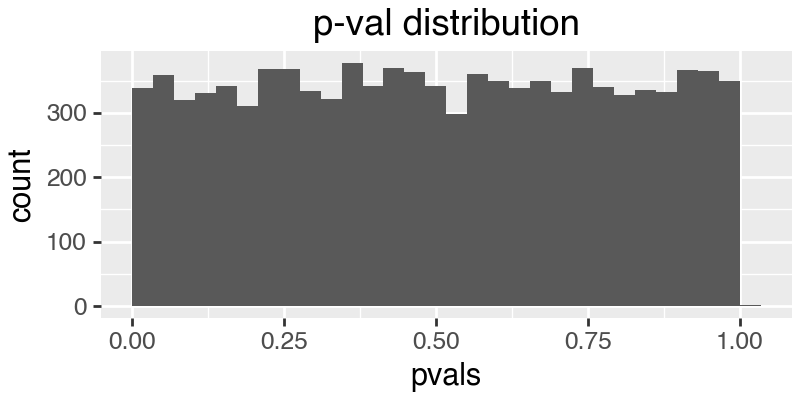

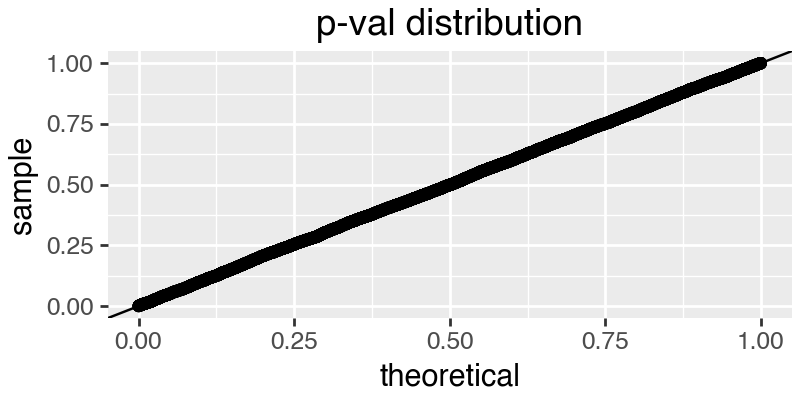

In [123]:
np.random.seed(10)
pvals0 = simulate_norm_groups(sample_size=50)
plot_pval(pvals0)

2. Correct for multiple testing

Adjust 𝑃-values with the different methods seen in the class. Plot the results using the plot function. Do
they behave as expected? Discuss.

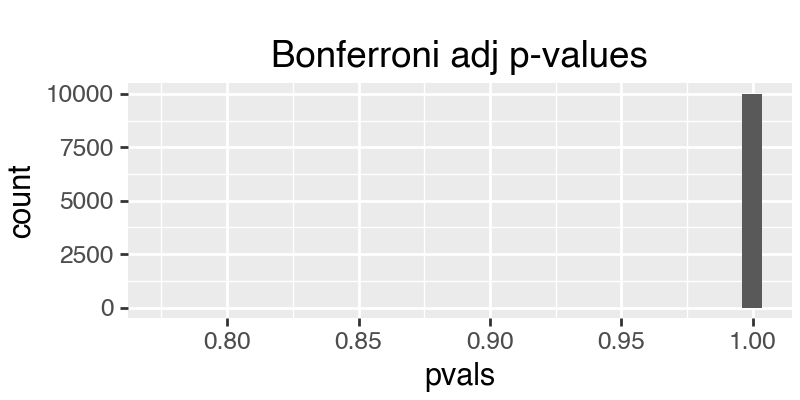

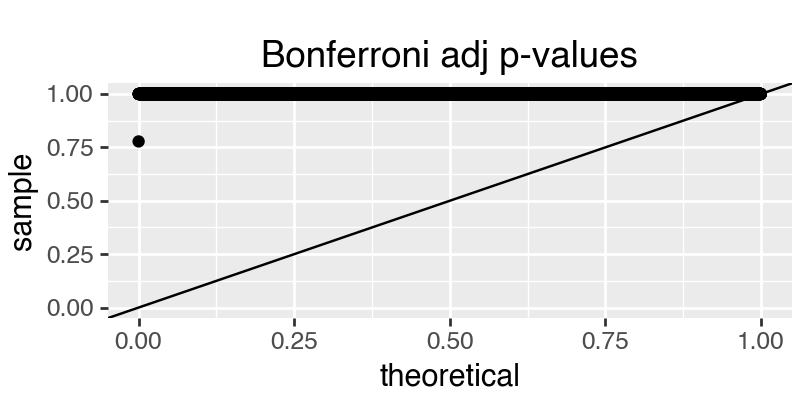

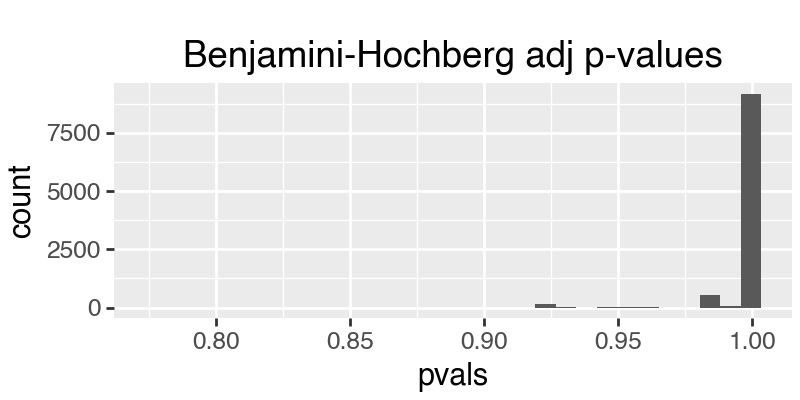

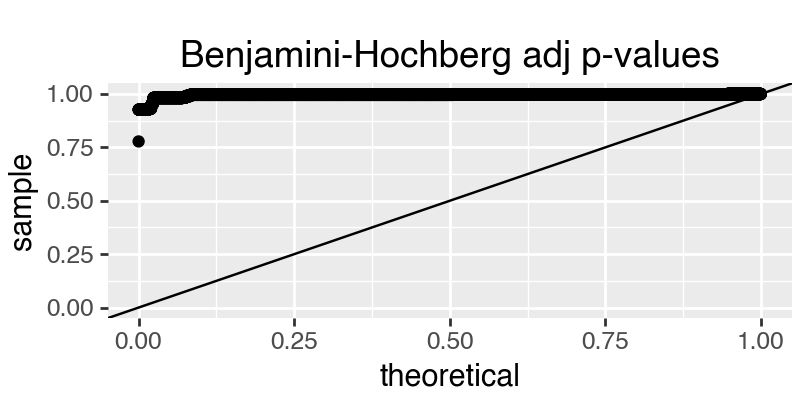

In [124]:
pvals0_B = multipletests(pvals0, method='bonferroni')[1]
plot_pval(pvals0_B, title="\nBonferroni adj p-values")

pvals0_BH = multipletests(pvals0, method='fdr_bh')[1]
plot_pval(pvals0_BH, title="\nBenjamini-Hochberg adj p-values")

The adjusted p-values do not behave as the nominal p-values. They do not come from a uniform
distribution and hence the histogram as well as the Q-Q plot looks skewed. This makes sense: our
adjustments account for the fact that p-values have a uniform distribution and multipel testing corrects
them upwards to remove false positives.

--------
# Section 05 - sample size and power

1. We will now simulate data under the alternative hypothesis 𝐻1
∶ 𝜇𝑥 ≠ 𝜇𝑦
. Specifically, we simulate two
samples 𝑥1
, ..., 𝑥𝑛 and 𝑦1
, ..., 𝑦𝑛 where 𝑋 and 𝑌 follow the normal distribution with 𝜇𝑥 = 0 and 𝜇𝑦 = 0.5
respectively. Do 𝑁 = 1, 000 experiments and investigate the effect of different sample sizes 𝑛 (10, 100, 1000) on the 𝑃-value plots. Discuss.

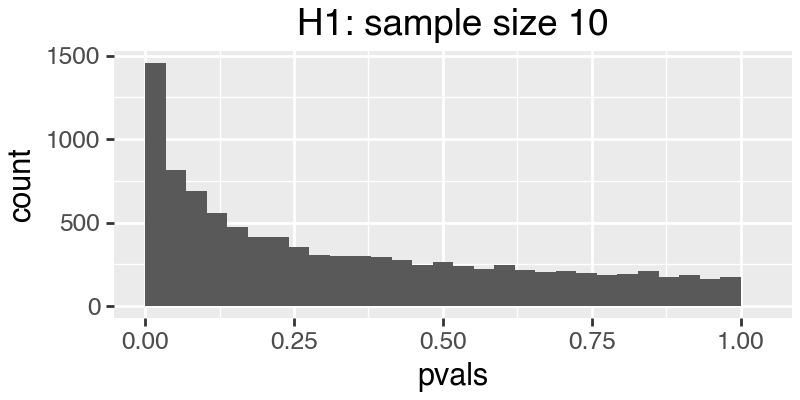

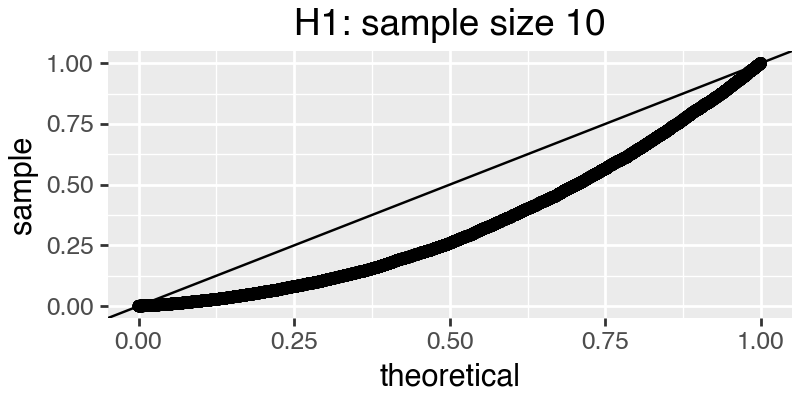

In [125]:
plot_pval(simulate_norm_groups(sample_size=10, mu_y=0.5), title="H1: sample size 10")

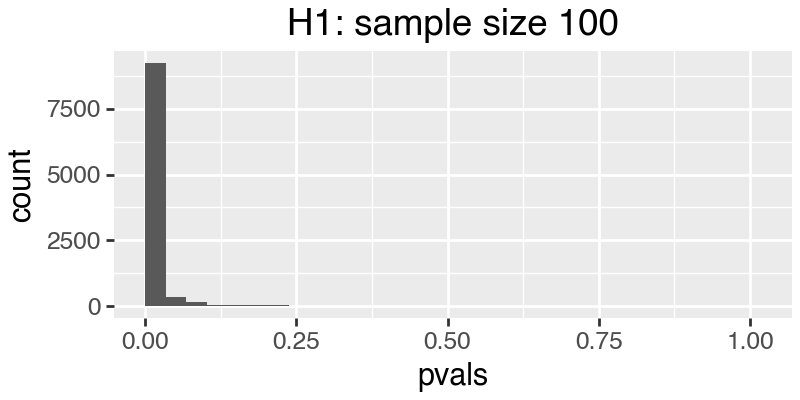

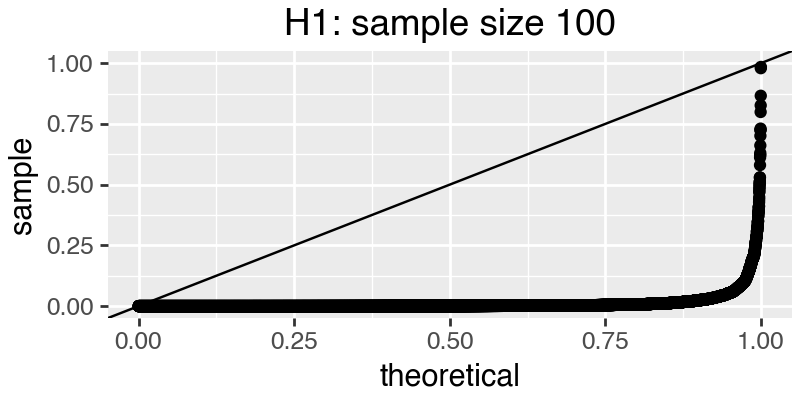

In [126]:
plot_pval(simulate_norm_groups(sample_size=100, mu_y=0.5), title="H1: sample size 100")

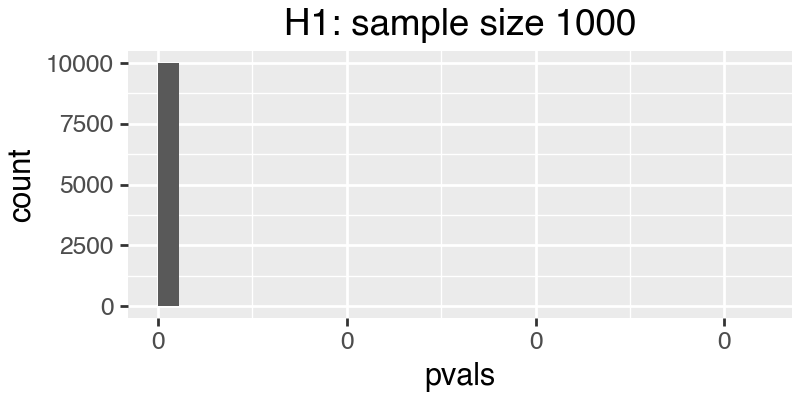

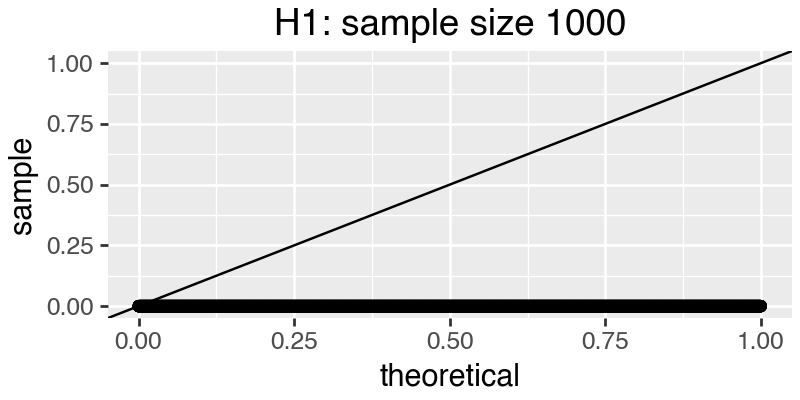

In [127]:
plot_pval(simulate_norm_groups(sample_size=1000, mu_y=0.5), title="H1: sample size 1000")

The higher the number of observations the lower the p-value gets. This means a tiny differences can be
found significant if one has enough observations.

2. 𝑃-values for a mixture of null and alternative.

Provide the same plots as before when considering a dataset of 𝑁0 = 10000 data points simulated under
𝐻0
(true null) and 𝑁1 = 1000 data points simulated under 𝐻1
(false null). Discuss.

You can also use a -log10 transformation, as in the tutorial, to better visualize the lower end of 𝑃-values.
The following function will allow us to plot the -log10 transformed 𝑃-values in a QQ-plot: